# **Chen Shmila**
# IEMOCAP Dataset  Exploratory Data Analysis


In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Global aesthetic settings ────────────────────────────────────────────
sns.set(style='whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

PALETTE_EMOTION = 'tab10'
PALETTE_GENDER  = {'M': 'steelblue', 'F': 'salmon'}
PALETTE_METHOD  = {'script': '#4c72b0', 'impro': '#dd8452'}


# <h1 style='color:purple;'>**Function Declaration and Implementation**</h1>


In [2]:
def plot_emotion_countplot(data, title='Emotion Label Distribution',
                           palette=PALETTE_EMOTION):
    """
    Bar chart of emotion label counts with annotated raw counts on top.
    Parameters:
    - data: DataFrame containing the IEMOCAP data
    - title: Title for the plot
    - palette: Seaborn colour palette name
    """
    order = data['emotion'].value_counts().index
    plt.figure(figsize=(12, 6))
    ax = sns.countplot(data=data, x='emotion', order=order, palette=palette)

    for p in ax.patches:
        ax.annotate(
            f'{int(p.get_height())}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=11, fontweight='bold', color='dimgray'
        )

    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Emotion Label', fontsize=13, color='darkblue')
    ax.set_ylabel('Count', fontsize=13, color='darkblue')
    plt.tight_layout()
    plt.show()


In [3]:
def plot_categorical_by_emotion(cat_feature, data, palette=PALETTE_EMOTION):
    """
    Grouped countplot: emotion on x-axis, hued by a categorical feature.
    Parameters:
    - cat_feature: Column name of the categorical feature used as hue
    - data: DataFrame containing the IEMOCAP data
    - palette: Seaborn colour palette
    """
    order = data['emotion'].value_counts().index
    plt.figure(figsize=(14, 6))
    ax = sns.countplot(data=data, x='emotion', hue=cat_feature,
                       order=order, palette=palette)
    ax.set_title(f'Emotion Distribution by {cat_feature.capitalize()}',
                 fontsize=15, fontweight='bold')
    ax.set_xlabel('Emotion Label', fontsize=13, color='darkblue')
    ax.set_ylabel('Count', fontsize=13, color='darkblue')
    ax.legend(title=cat_feature.capitalize(), fontsize=11)
    plt.tight_layout()
    plt.show()


In [4]:
def plot_numeric_by_emotion(numeric_feature, data, order=None):
    """
    Combined boxplot + stripplot of a numeric feature grouped by emotion label.
    Parameters:
    - numeric_feature: Column name of the numeric feature to visualize
    - data: DataFrame containing the IEMOCAP data
    - order: Optional list of emotion labels controlling x-axis order
    """
    if order is None:
        order = data['emotion'].value_counts().index.tolist()
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=data, x='emotion', y=numeric_feature,
                order=order, palette=PALETTE_EMOTION,
                width=0.5, fliersize=0)
    sns.stripplot(data=data, x='emotion', y=numeric_feature,
                  order=order, color='black', alpha=0.25, size=2.5, jitter=True)
    plt.title(f'{numeric_feature.replace("_", " ").title()} by Emotion',
              fontsize=15, fontweight='bold')
    plt.xlabel('Emotion Label', fontsize=13, color='darkblue')
    plt.ylabel(numeric_feature.replace('_', ' ').title(), fontsize=13, color='darkblue')
    plt.tight_layout()
    plt.show()


In [5]:
def plot_session_emotion_heatmap(data, normalize=False,
                                  title='Session × Emotion Count Heatmap'):
    """
    Pivot-table heatmap showing how emotions distribute across sessions.
    Parameters:
    - data: DataFrame containing the IEMOCAP data
    - normalize: If True, normalise counts row-wise (proportion per session)
    - title: Plot title
    """
    pivot = pd.crosstab(data['session'], data['emotion'])
    if normalize:
        pivot = pivot.div(pivot.sum(axis=1), axis=0).round(3)
    plt.figure(figsize=(14, 6))
    sns.heatmap(pivot, annot=True,
                fmt='.2f' if normalize else 'd',
                cmap='YlOrRd', linewidths=0.5)
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('Emotion Label', fontsize=12, color='darkblue')
    plt.ylabel('Session', fontsize=12, color='darkblue')
    plt.tight_layout()
    plt.show()


In [6]:
def plot_crosstab_heatmap(row_feat, col_feat, data, normalize=True):
    """
    Generic cross-tabulation heatmap between any two categorical columns.
    Parameters:
    - row_feat: Column name for heatmap rows
    - col_feat: Column name for heatmap columns
    - data: DataFrame containing the IEMOCAP data
    - normalize: If True, normalise row-wise to show proportions
    """
    pivot = pd.crosstab(data[row_feat], data[col_feat])
    if normalize:
        pivot = pivot.div(pivot.sum(axis=1), axis=0).round(3)
    plt.figure(figsize=(max(8, len(pivot.columns) * 1.2), 5))
    sns.heatmap(pivot, annot=True,
                fmt='.2f' if normalize else 'd',
                cmap='Blues', linewidths=0.4)
    label_fmt = '(proportion)' if normalize else '(count)'
    plt.title(f'{row_feat.capitalize()} × {col_feat.capitalize()} {label_fmt}',
              fontsize=14, fontweight='bold')
    plt.xlabel(col_feat.capitalize(), fontsize=12, color='darkblue')
    plt.ylabel(row_feat.capitalize(), fontsize=12, color='darkblue')
    plt.tight_layout()
    plt.show()


In [7]:
def plot_correlation_heatmap(data, cols, title='Feature Correlation Heatmap'):
    """
    Pearson correlation heatmap with annotations for the given numeric columns.
    Parameters:
    - data: DataFrame containing the IEMOCAP data
    - cols: List of numeric column names to include
    - title: Plot title
    """
    cor_mat = data[cols].corr(method='pearson')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cor_mat, annot=True, cmap='coolwarm', fmt='.4f',
                vmin=-1, vmax=1, linewidths=0.5)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# <h1 style='color:purple;'>**Import Data**</h1>


In [8]:
DATA_PATH = os.path.join(os.pardir, 'data', 'iemocap_full_dataset.csv')
df = pd.read_csv(DATA_PATH)


In [9]:
df.head()


,session,method,gender,emotion,n_annotators,agreement,path
0,1,script,F,neu,3,3,Session1/sentences/wav/Ses01F_script02_1/Ses01...
1,1,script,F,fru,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...
2,1,script,F,xxx,0,0,Session1/sentences/wav/Ses01F_script02_1/Ses01...
3,1,script,F,sur,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...
4,1,script,F,neu,3,2,Session1/sentences/wav/Ses01F_script02_1/Ses01...


In [10]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10039 entries, 0 to 10038
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   session       10039 non-null  int64
 1   method        10039 non-null  str  
 2   gender        10039 non-null  str  
 3   emotion       10039 non-null  str  
 4   n_annotators  10039 non-null  int64
 5   agreement     10039 non-null  int64
 6   path          10039 non-null  str  
dtypes: int64(3), str(4)
memory usage: 549.1 KB


The dataset contains audio-file level annotations from the **IEMOCAP corpus** (Interactive Emotional Dyadic Motion Capture). Each row represents a single audio utterance labelled with an emotion category, along with metadata about the recording session, speaker gender, elicitation method, and annotator agreement.


In [11]:
df.describe().round(2)


,session,n_annotators,agreement
count,10039.0,10039.00,10039.00
mean,3.1,2.45,1.86
std,1.4,1.47,1.20
min,1.0,0.00,0.00
25%,2.0,3.00,2.00
50%,3.0,3.00,2.00
75%,4.0,3.00,3.00
max,5.0,4.00,4.00


In [12]:
df.shape


(10039, 7)

# <h1 style='color:purple;'>**Data Cleaning & EDA  Exploratory Data Analysis**</h1>


In [13]:
# Raw count of missing values per column
print(df.isnull().sum())


session         0
method          0
gender          0
emotion         0
n_annotators    0
agreement       0
path            0
dtype: int64


In [14]:
# Percentage of missing values per column
(df.isnull().sum() / len(df) * 100).round(4)


session         0.0
method          0.0
gender          0.0
emotion         0.0
n_annotators    0.0
agreement       0.0
path            0.0
dtype: float64

<u>**Missing value strategy:**</u>  
The dataset contains **no missing values**, so no imputation is required.  
However, the `emotion` column includes the label **`xxx`** (2 507 occurrences ≈ 25 % of the data), which denotes utterances whose emotion was ambiguous or not agreed upon by annotators.  

We will maintain **two analytical views**:  
1. `cData`  the full dataset including `xxx` (used for annotation-quality analysis).  
2. `cData_core`  filtered to the **six primary acted emotions** (`neu`, `fru`, `ang`, `sad`, `exc`, `hap`) for focused emotional content analysis.


In [15]:
cData = df.copy()

CORE_EMOTIONS = ['neu', 'fru', 'ang', 'sad', 'exc', 'hap']
cData_core = cData[cData['emotion'].isin(CORE_EMOTIONS)].copy()

print(f'Full dataset  : {cData.shape[0]:,} rows')
print(f'Core emotions : {cData_core.shape[0]:,} rows')


Full dataset  : 10,039 rows
Core emotions : 7,380 rows


In [16]:
# Verify numeric ranges are consistent
print('n_annotators unique values:', sorted(cData['n_annotators'].unique()))
print('agreement     unique values:', sorted(cData['agreement'].unique()))
print('session       unique values:', sorted(cData['session'].unique()))

# Confirm no agreement value exceeds n_annotators
invalid = cData[cData['agreement'] > cData['n_annotators']]
print(f'\nRows where agreement > n_annotators: {len(invalid)}')


n_annotators unique values: [np.int64(0), np.int64(3), np.int64(4)]
agreement     unique values: [np.int64(0), np.int64(2), np.int64(3), np.int64(4)]
session       unique values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Rows where agreement > n_annotators: 0


3 as expected (sessions 1–5, binary gender, binary method).  
All `agreement` values are within `[0, n_annotators]`, confirming data integrity.


In [17]:
# Agreement ratio: normalised consensus score per utterance
cData['agreement_ratio'] = np.where(
    cData['n_annotators'] > 0,
    cData['agreement'] / cData['n_annotators'],
    np.nan
)
cData_core['agreement_ratio'] = np.where(
    cData_core['n_annotators'] > 0,
    cData_core['agreement'] / cData_core['n_annotators'],
    np.nan
)
print('agreement_ratio stats:')
print(cData['agreement_ratio'].describe().round(3))


agreement_ratio stats:
count    7532.000
mean        0.759
std         0.163
min         0.500
25%         0.667
50%         0.667
75%         1.000
max         1.000
Name: agreement_ratio, dtype: float64


---
## 5.1 Emotion Label Distribution


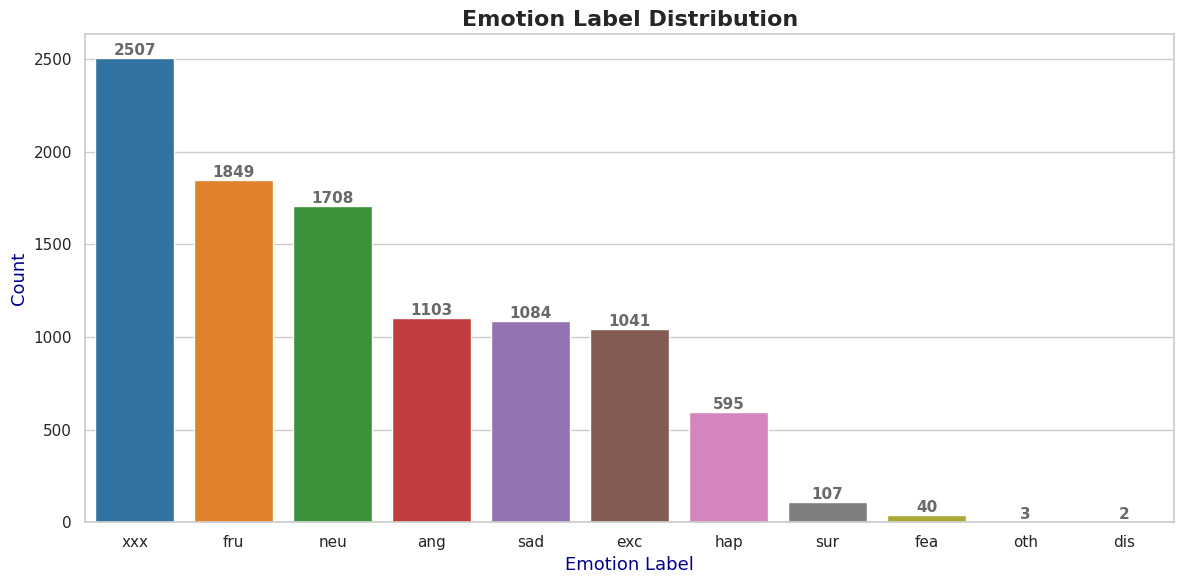

In [18]:
plot_emotion_countplot(cData)


<u>**Observations (full label set):**</u>

1. The label `xxx` is by far the most frequent (~25 %), representing utterances with no agreed emotion  a notable class-imbalance in the corpus.
2. Among the acted emotion classes, `fru` (frustration) dominates, followed by `neu` (neutral), `ang` (anger), and `sad` (sadness).
3. `hap` (happiness) is surprisingly rare compared to `exc` (excitement), suggesting annotators used the two labels differently.
4. `sur`, `fea`, `oth`, and `dis` together account for fewer than 200 samples  these are extreme minority categories that deserve special attention in any analysis.


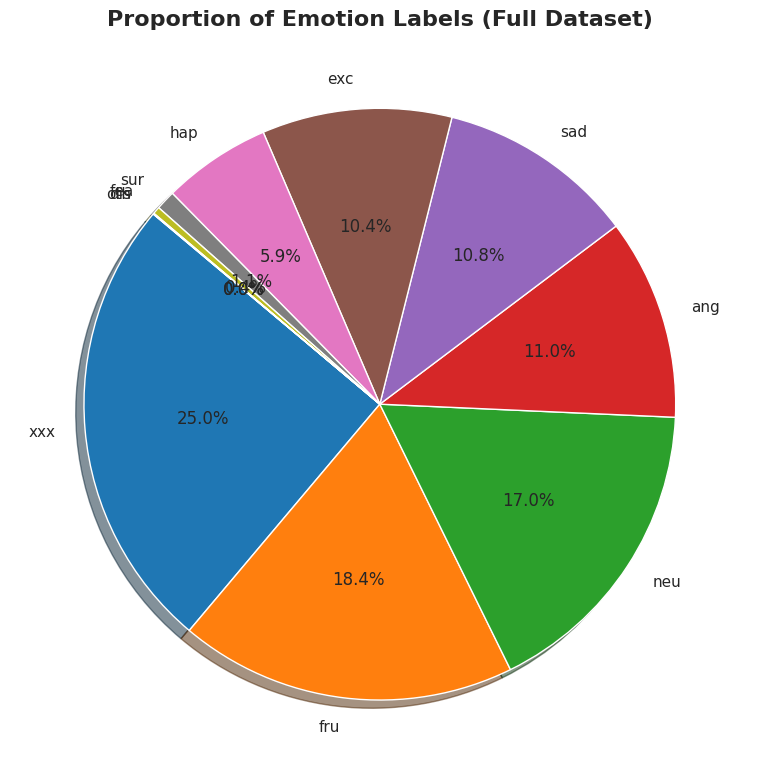

In [19]:
emotion_counts = cData['emotion'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(
    emotion_counts,
    labels=emotion_counts.index,
    autopct='%1.1f%%',
    shadow=True,
    startangle=140,
    colors=sns.color_palette(PALETTE_EMOTION, len(emotion_counts))
)
plt.title('Proportion of Emotion Labels (Full Dataset)', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


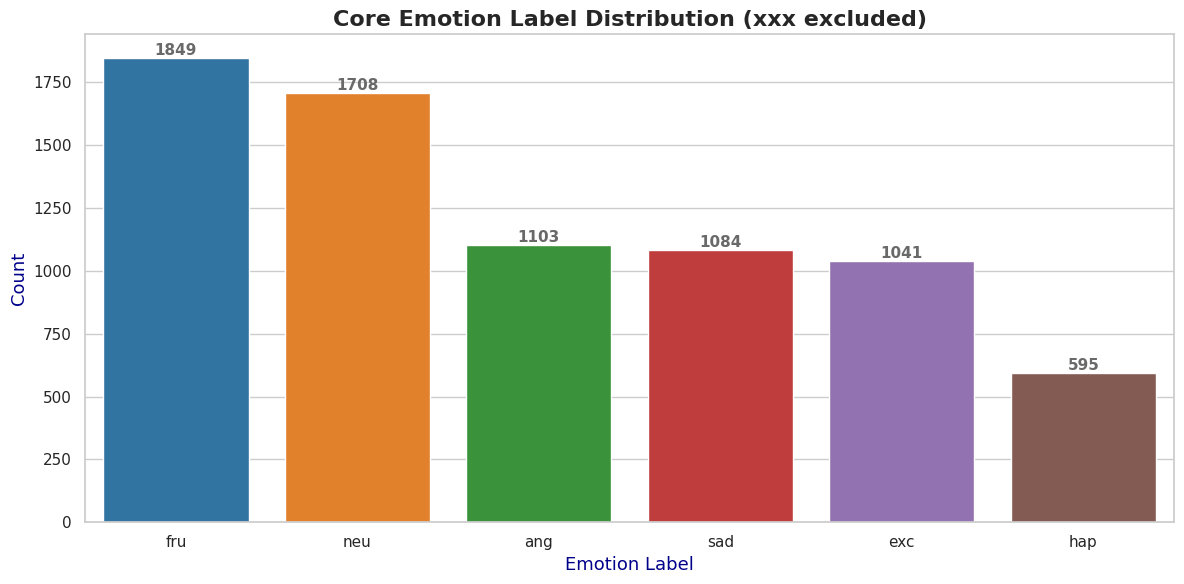

In [20]:
plot_emotion_countplot(cData_core, title='Core Emotion Label Distribution (xxx excluded)')


After excluding `xxx`, the six core emotion classes remain heavily imbalanced. `fru` has roughly **3×** the samples of `hap`, making this a notably skewed dataset worth keeping in mind throughout all subsequent analyses.


---
## 5.2 Gender & Method (Script vs Improvised) Analysis


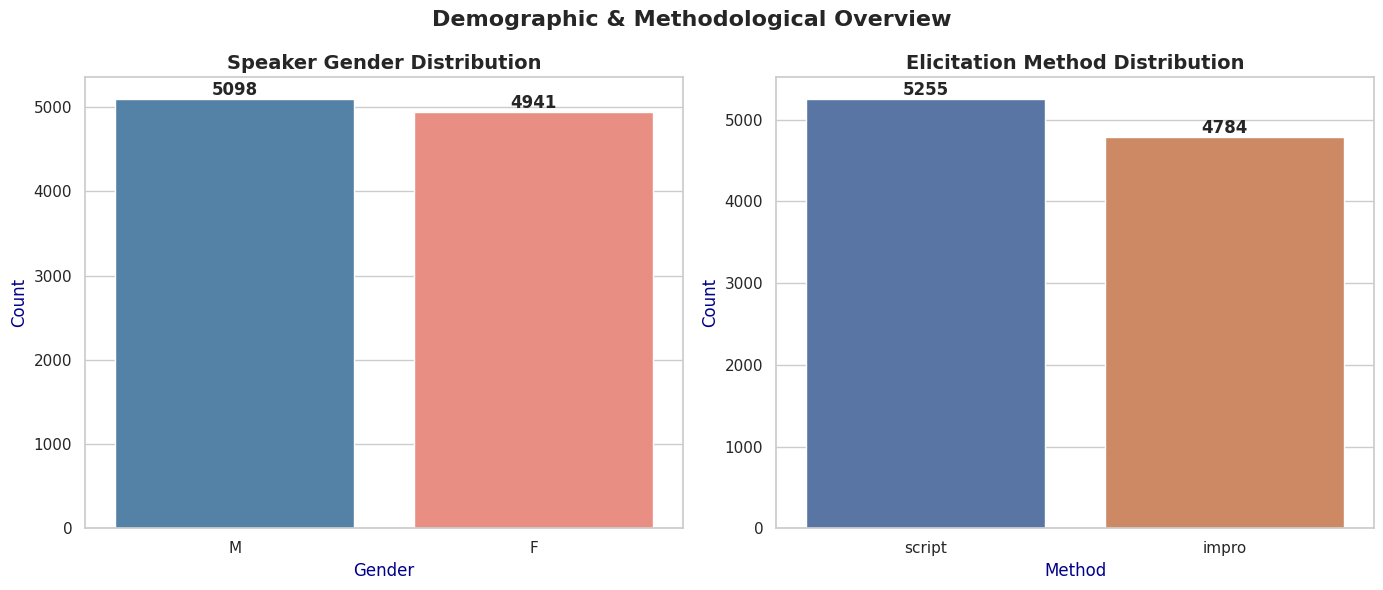

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gender distribution
gender_counts = cData['gender'].value_counts()
sns.barplot(x=gender_counts.index, y=gender_counts.values,
            palette=PALETTE_GENDER, ax=axes[0])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Speaker Gender Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12, color='darkblue')
axes[0].set_ylabel('Count', fontsize=12, color='darkblue')

# Method distribution
method_counts = cData['method'].value_counts()
sns.barplot(x=method_counts.index, y=method_counts.values,
            palette=PALETTE_METHOD, ax=axes[1])
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[1].set_title('Elicitation Method Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Method', fontsize=12, color='darkblue')
axes[1].set_ylabel('Count', fontsize=12, color='darkblue')

fig.suptitle('Demographic & Methodological Overview', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


<u>Gender & Method balance:</u>  
- Gender is nearly perfectly balanced (~51 % M, ~49 % F)  no gender bias in data collection.  
- Script and improvised sessions are also near-equal (~52 % script, ~48 % impro), allowing fair method comparisons.


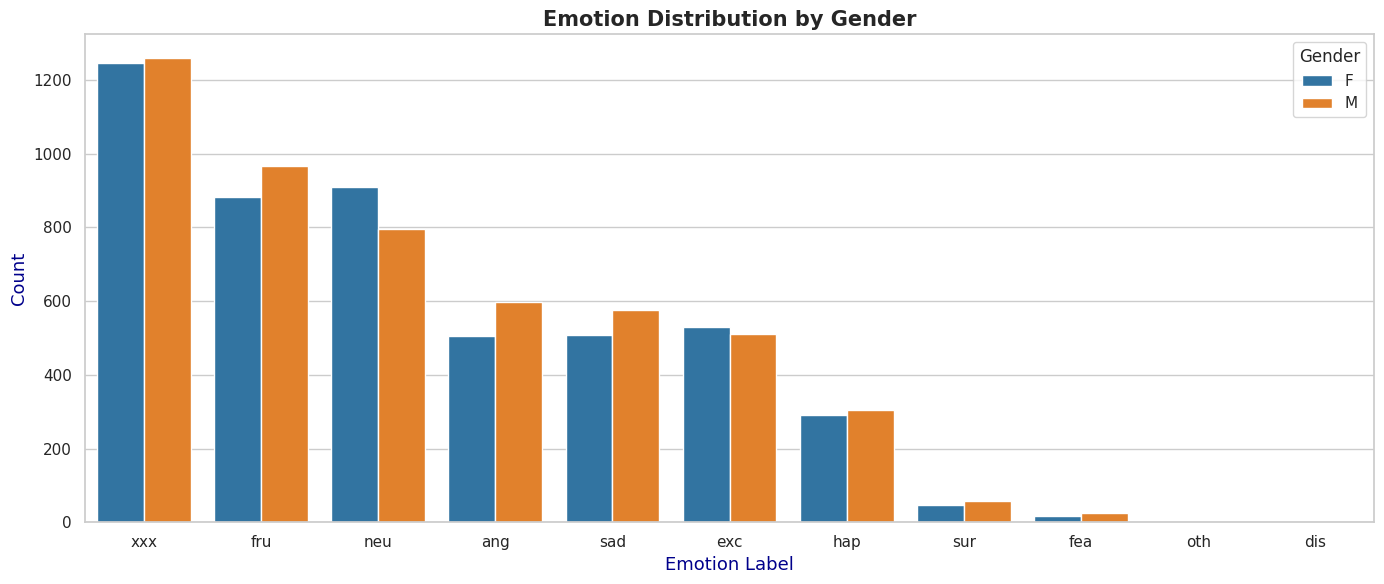

In [22]:
plot_categorical_by_emotion('gender', cData)


<u>Gender × Emotion observations:</u>

1. Male and female speaker counts are roughly proportional across most emotion classes, confirming balanced representation.
2. `xxx` (unlabelled) is similarly distributed across genders, suggesting ambiguity is not a gender-specific phenomenon.
3. `exc` (excitement) shows a slight male dominance; `sad` has a slightly higher female count.


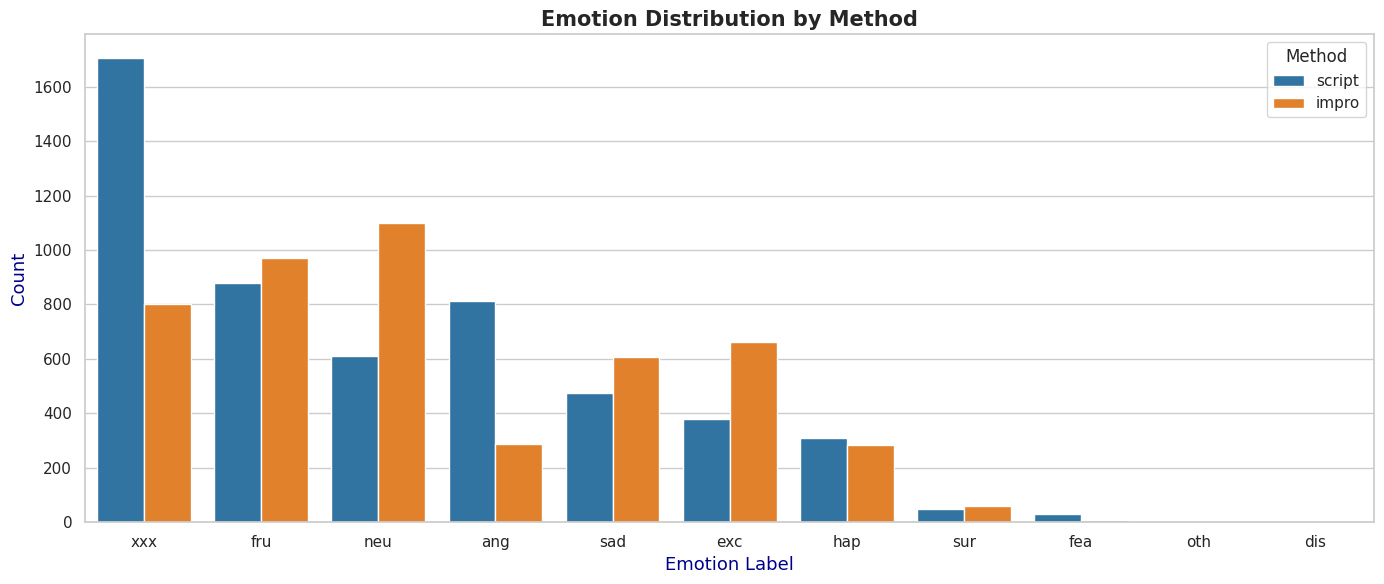

In [23]:
plot_categorical_by_emotion('method', cData)


<u>Method × Emotion observations:</u>

1. `fru` (frustration) appears almost exclusively in **improvised** sessions, which aligns with naturalistic spontaneous elicitation protocols.
2. `xxx` is spread across both methods, though slightly more prevalent in scripted sessions.
3. Scripted sessions tend to produce cleaner, more agreed-upon emotion labels (lower `xxx` proportion relative to the total scripted count).


---
## 5.3 Session Analysis


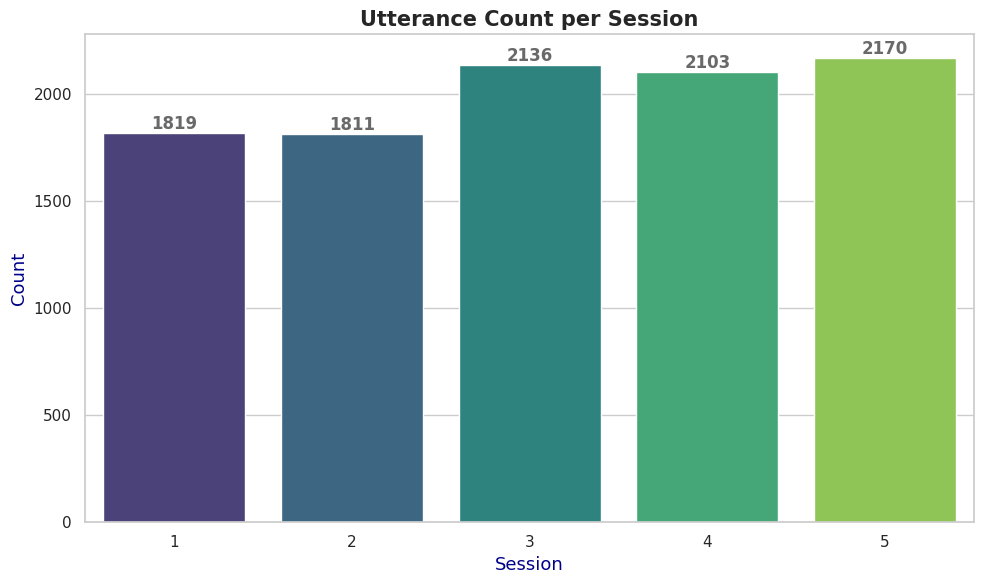

In [24]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=cData, x='session',
                   palette='viridis', order=sorted(cData['session'].unique()))
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='dimgray')
ax.set_title('Utterance Count per Session', fontsize=15, fontweight='bold')
ax.set_xlabel('Session', fontsize=13, color='darkblue')
ax.set_ylabel('Count', fontsize=13, color='darkblue')
plt.tight_layout()
plt.show()


Sessions 3–5 contain slightly more utterances than sessions 1–2 (~20 % difference). This is a mild structural imbalance worth noting when comparing across sessions.


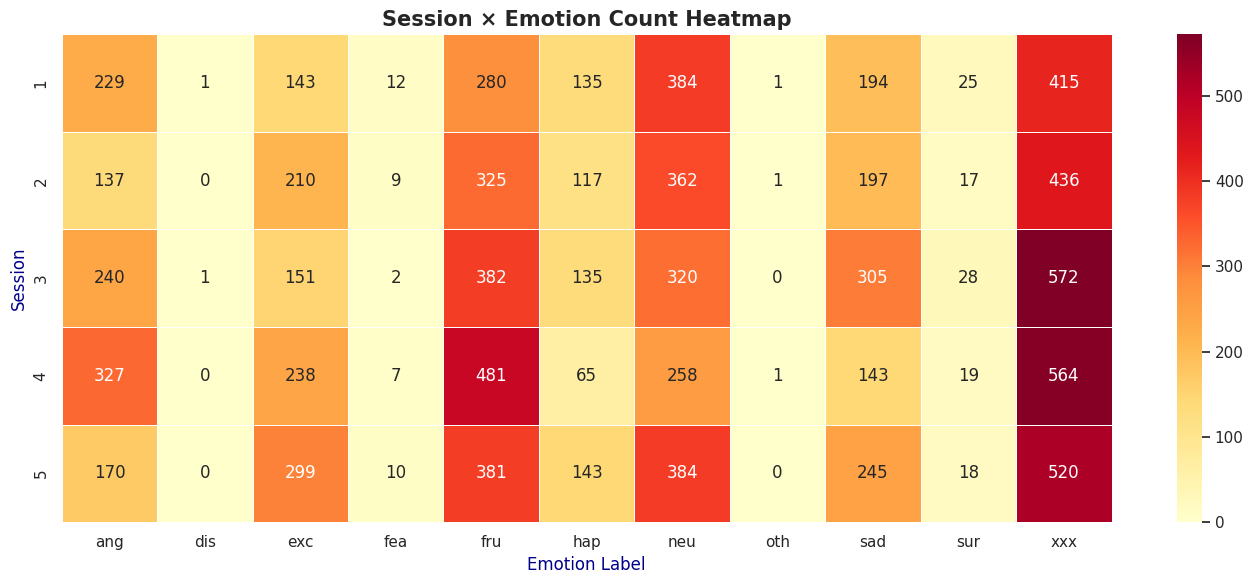

In [25]:
plot_session_emotion_heatmap(cData)


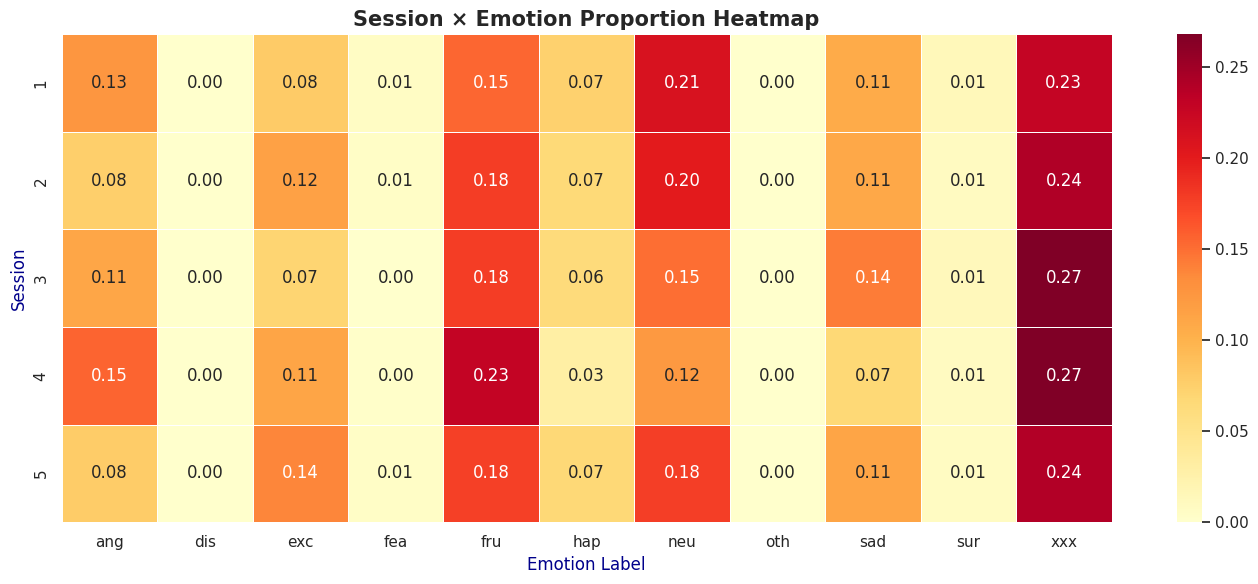

In [26]:
plot_session_emotion_heatmap(cData, normalize=True,
                             title='Session × Emotion Proportion Heatmap')


<u>Session × Emotion observations:</u>

1. `fru` is concentrated in sessions 1 and 3–5 with minimal presence in session 2, suggesting session-specific scripting choices.
2. `xxx` proportions are relatively stable across sessions (~0.24–0.27), indicating annotation ambiguity is a data-wide characteristic, not session-specific.
3. `exc` (excitement) is more prominent in sessions 4 and 5, possibly reflecting actor-specific variation.


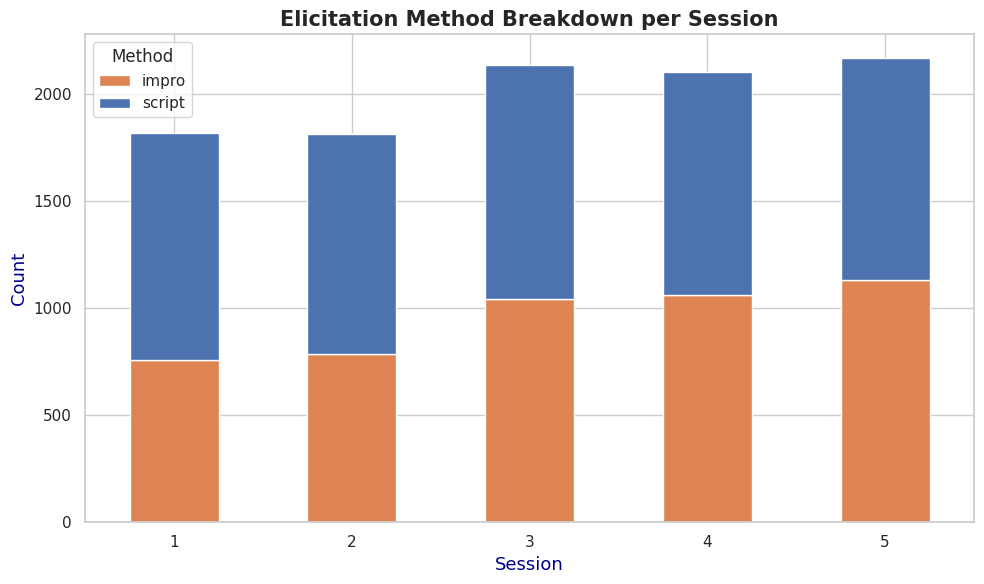

In [27]:
# Stacked bar: method split within each session
method_session = pd.crosstab(cData['session'], cData['method'])
method_session.plot(kind='bar', stacked=True, figsize=(10, 6),
                    color=[PALETTE_METHOD['impro'], PALETTE_METHOD['script']])
plt.title('Elicitation Method Breakdown per Session', fontsize=15, fontweight='bold')
plt.xlabel('Session', fontsize=13, color='darkblue')
plt.ylabel('Count', fontsize=13, color='darkblue')
plt.xticks(rotation=0)
plt.legend(title='Method', fontsize=11)
plt.tight_layout()
plt.show()


Each session contains both scripted and improvised portions, with the split varying by session. Session 2 leans more heavily scripted, while sessions 3 and 5 are more improvisation-dominant.


---
## 5.4 Annotator Agreement & Label Quality Analysis


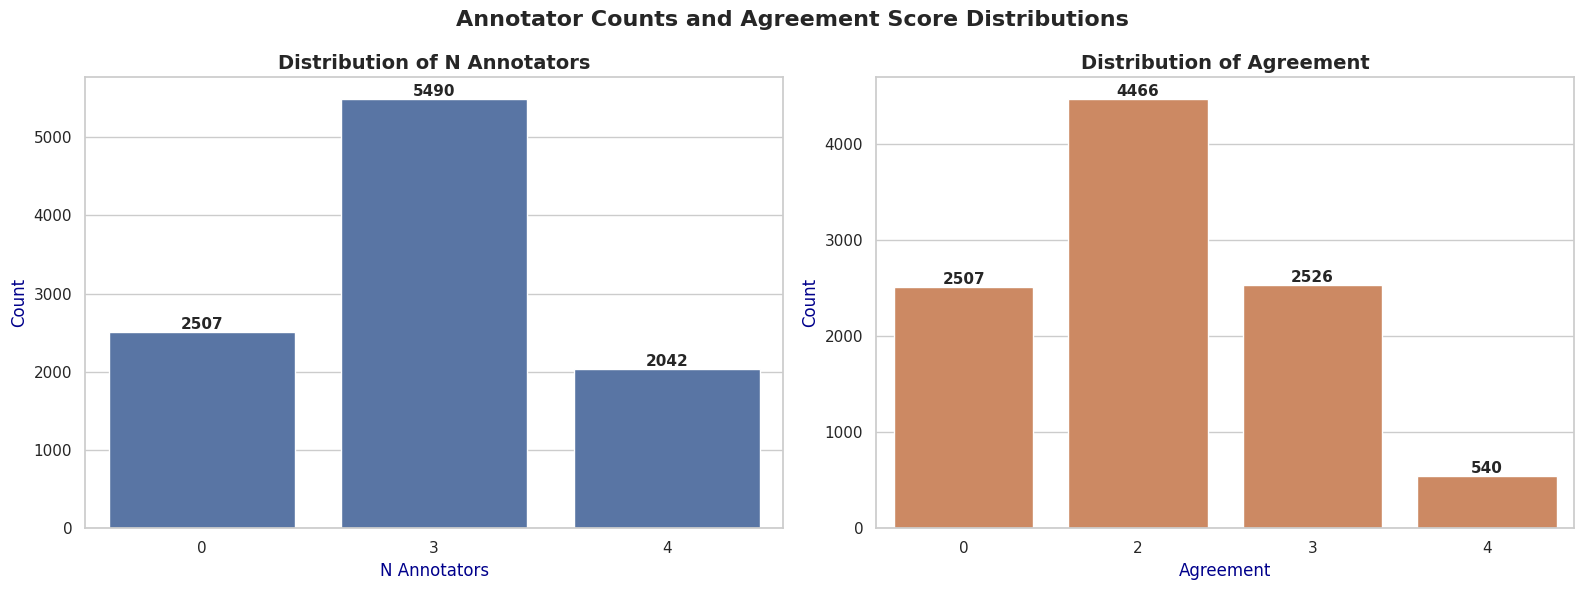

In [28]:
# Side-by-side histograms for n_annotators and agreement
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, col, color in zip(axes,
                           ['n_annotators', 'agreement'],
                           ['#4c72b0', '#dd8452']):
    counts = cData[col].value_counts().sort_index()
    sns.barplot(x=counts.index, y=counts.values, color=color, ax=ax)
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of {col.replace("_", " ").title()}',
                 fontsize=14, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title(), fontsize=12, color='darkblue')
    ax.set_ylabel('Count', fontsize=12, color='darkblue')

fig.suptitle('Annotator Counts and Agreement Score Distributions',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


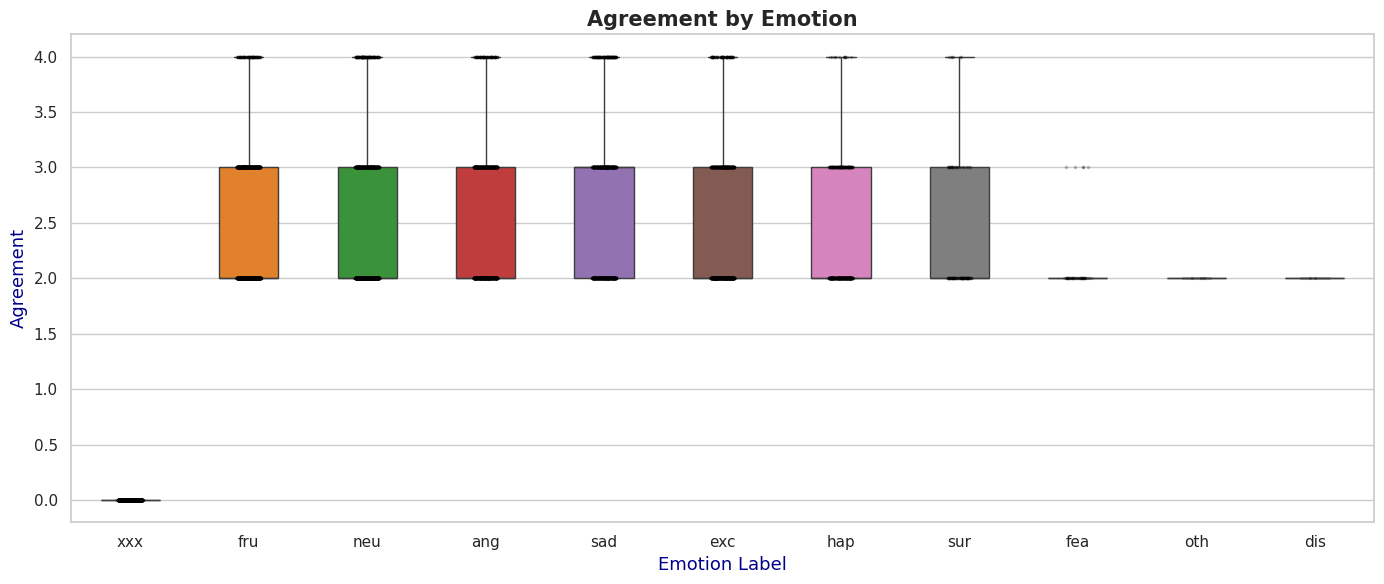

In [29]:
plot_numeric_by_emotion('agreement', cData)


<u>Agreement × Emotion observations:</u>

1. `xxx` utterances have the **lowest median agreement** (~1), confirming they represent genuinely ambiguous or disagreed-upon content.
2. `ang` (anger) and `hap` (happiness) show the **highest agreement**, suggesting these emotions are most consistently identifiable.
3. `fru` (frustration) has surprisingly high variance in agreement, which may reflect blending with `ang` or `sad` in some utterances.


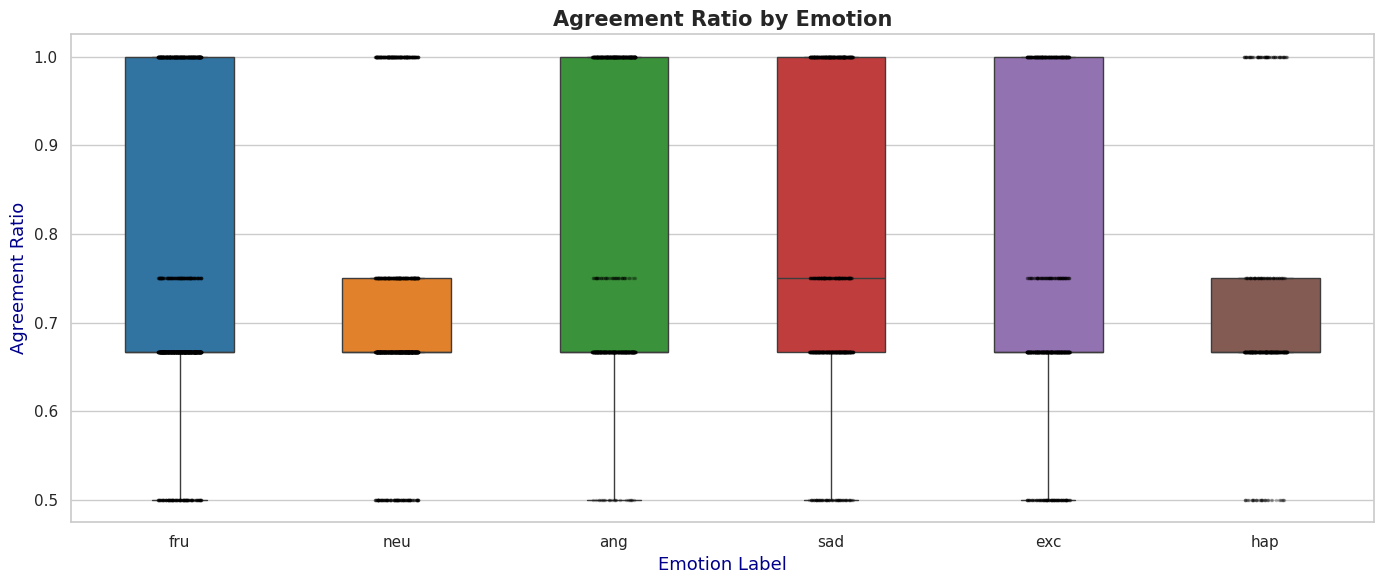

In [30]:
plot_numeric_by_emotion('agreement_ratio', cData_core)


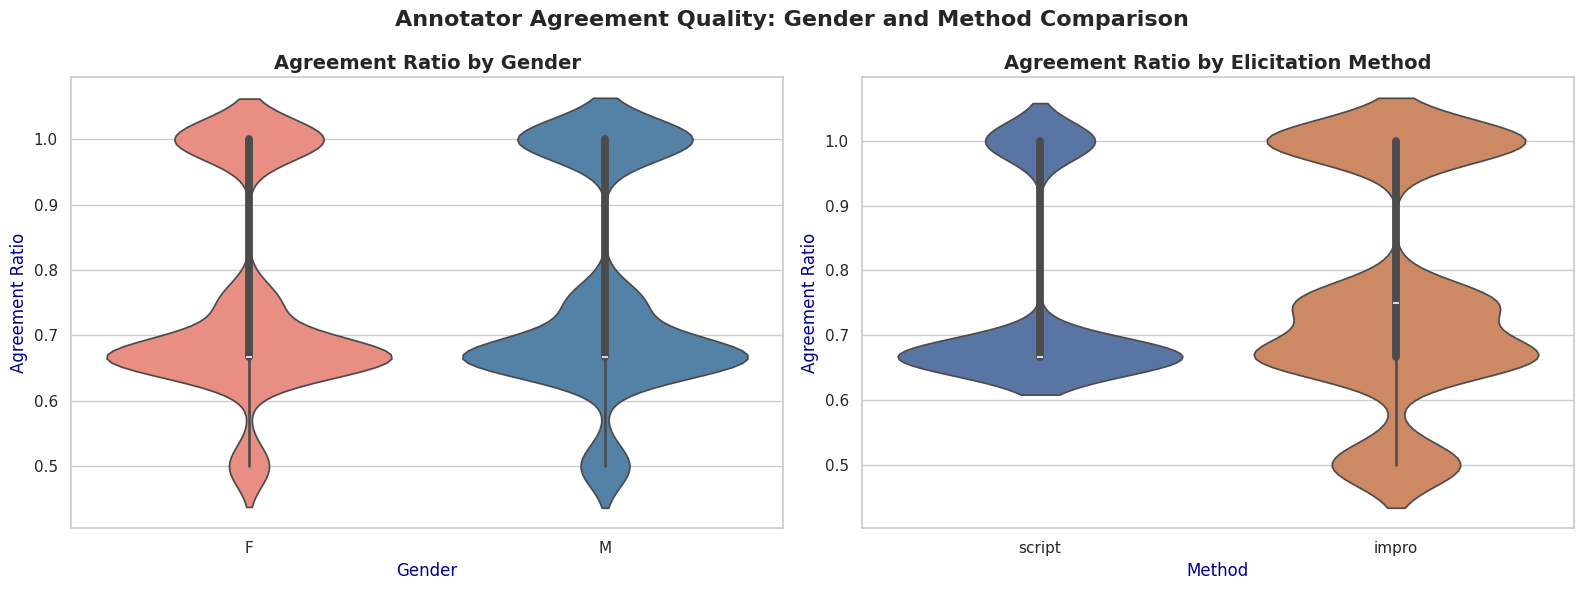

In [31]:
# Agreement ratio by gender and method  side by side violinplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=cData_core, x='gender', y='agreement_ratio',
               palette=PALETTE_GENDER, inner='box', ax=axes[0])
axes[0].set_title('Agreement Ratio by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12, color='darkblue')
axes[0].set_ylabel('Agreement Ratio', fontsize=12, color='darkblue')

sns.violinplot(data=cData_core, x='method', y='agreement_ratio',
               palette=PALETTE_METHOD, inner='box', ax=axes[1])
axes[1].set_title('Agreement Ratio by Elicitation Method', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Method', fontsize=12, color='darkblue')
axes[1].set_ylabel('Agreement Ratio', fontsize=12, color='darkblue')

fig.suptitle('Annotator Agreement Quality: Gender and Method Comparison',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


<u>Agreement ratio observations:</u>

1. **Gender**: Agreement ratios are nearly identical between male and female speakers, indicating that the clarity of emotional expression is not gender-dependent in this corpus.
2. **Method**: Scripted sessions achieve a marginally higher median agreement ratio, consistent with actors following predefined emotional scripts being more unambiguous in their portrayals compared to improvised interactions.


---
## 5.5 Cross-Dimensional Analysis


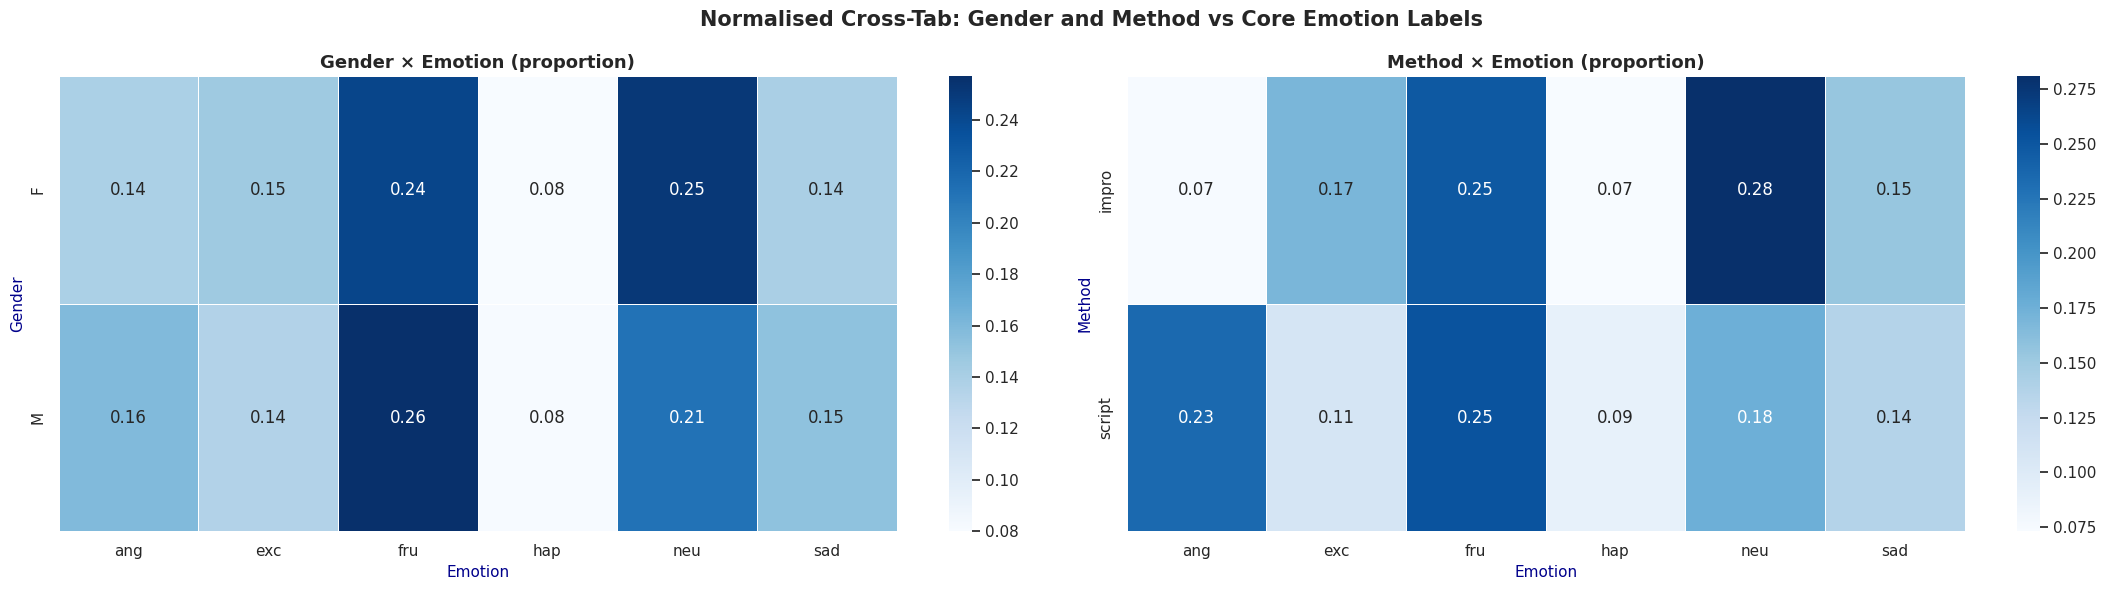

In [32]:
# Side-by-side cross-tab heatmaps: gender×emotion and method×emotion
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

for ax, row_feat in zip(axes, ['gender', 'method']):
    pivot = pd.crosstab(cData_core[row_feat], cData_core['emotion'])
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0).round(3)
    sns.heatmap(pivot_norm, annot=True, fmt='.2f', cmap='Blues',
                linewidths=0.4, ax=ax)
    ax.set_title(f'{row_feat.capitalize()} × Emotion (proportion)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Emotion', fontsize=11, color='darkblue')
    ax.set_ylabel(row_feat.capitalize(), fontsize=11, color='darkblue')

plt.suptitle('Normalised Cross-Tab: Gender and Method vs Core Emotion Labels',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


<u>Cross-tab observations:</u>

1. **Gender × Emotion**: Emotion proportions are nearly identical for M and F, confirming that the corpus was designed with gender balance in mind.
2. **Method × Emotion**: Scripted sessions have a higher proportion of `neu` and `sad`, while improvised sessions contain significantly more `fru`  reflecting the natural emergence of frustration in unscripted interactions.


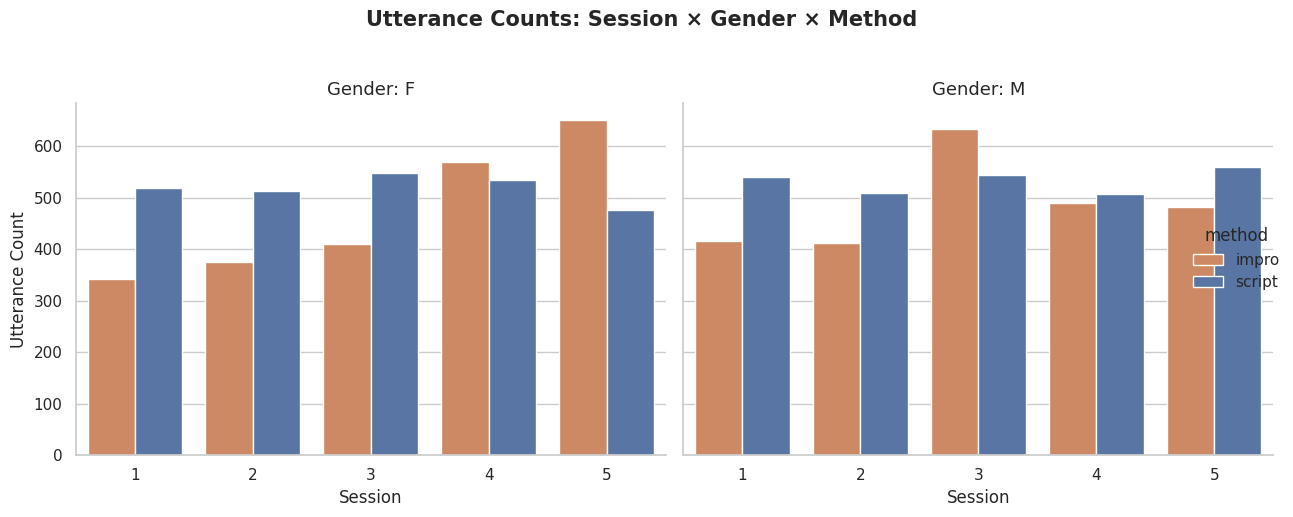

In [33]:
# 3-way facet: Gender × Session, colored by method
temp = cData.groupby(['session', 'gender', 'method']).size().reset_index(name='count')

g = sns.catplot(
    data=temp, x='session', y='count', hue='method',
    col='gender', kind='bar',
    palette=PALETTE_METHOD, height=5, aspect=1.2
)
g.set_titles(col_template='Gender: {col_name}', size=13)
g.set_axis_labels('Session', 'Utterance Count')
g.fig.suptitle('Utterance Counts: Session × Gender × Method', y=1.03,
               fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


The facet plot confirms that both genders follow the same session-method pattern, ruling out any gender × method confound in the data collection design.


---
## 5.6 Annotator Count Distribution by Emotion


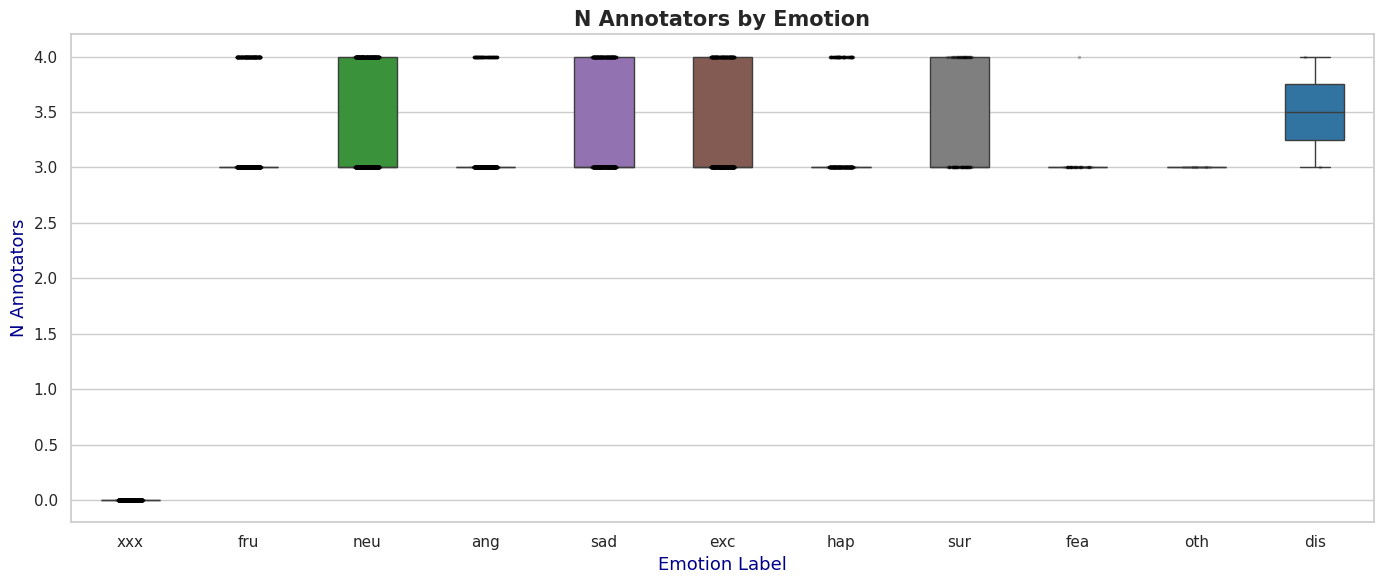

In [34]:
plot_numeric_by_emotion('n_annotators', cData)


Most utterances received exactly 3 annotations. Some receive 4 (where a tie-breaking fourth annotation was solicited), and a small number have fewer than 3, typically due to data collection issues. The `xxx` category shows more variance in annotator count, suggesting that additional annotations were sought for ambiguous utterances.


---
## 5.7 Detailed Feature Distributions by Core Emotion


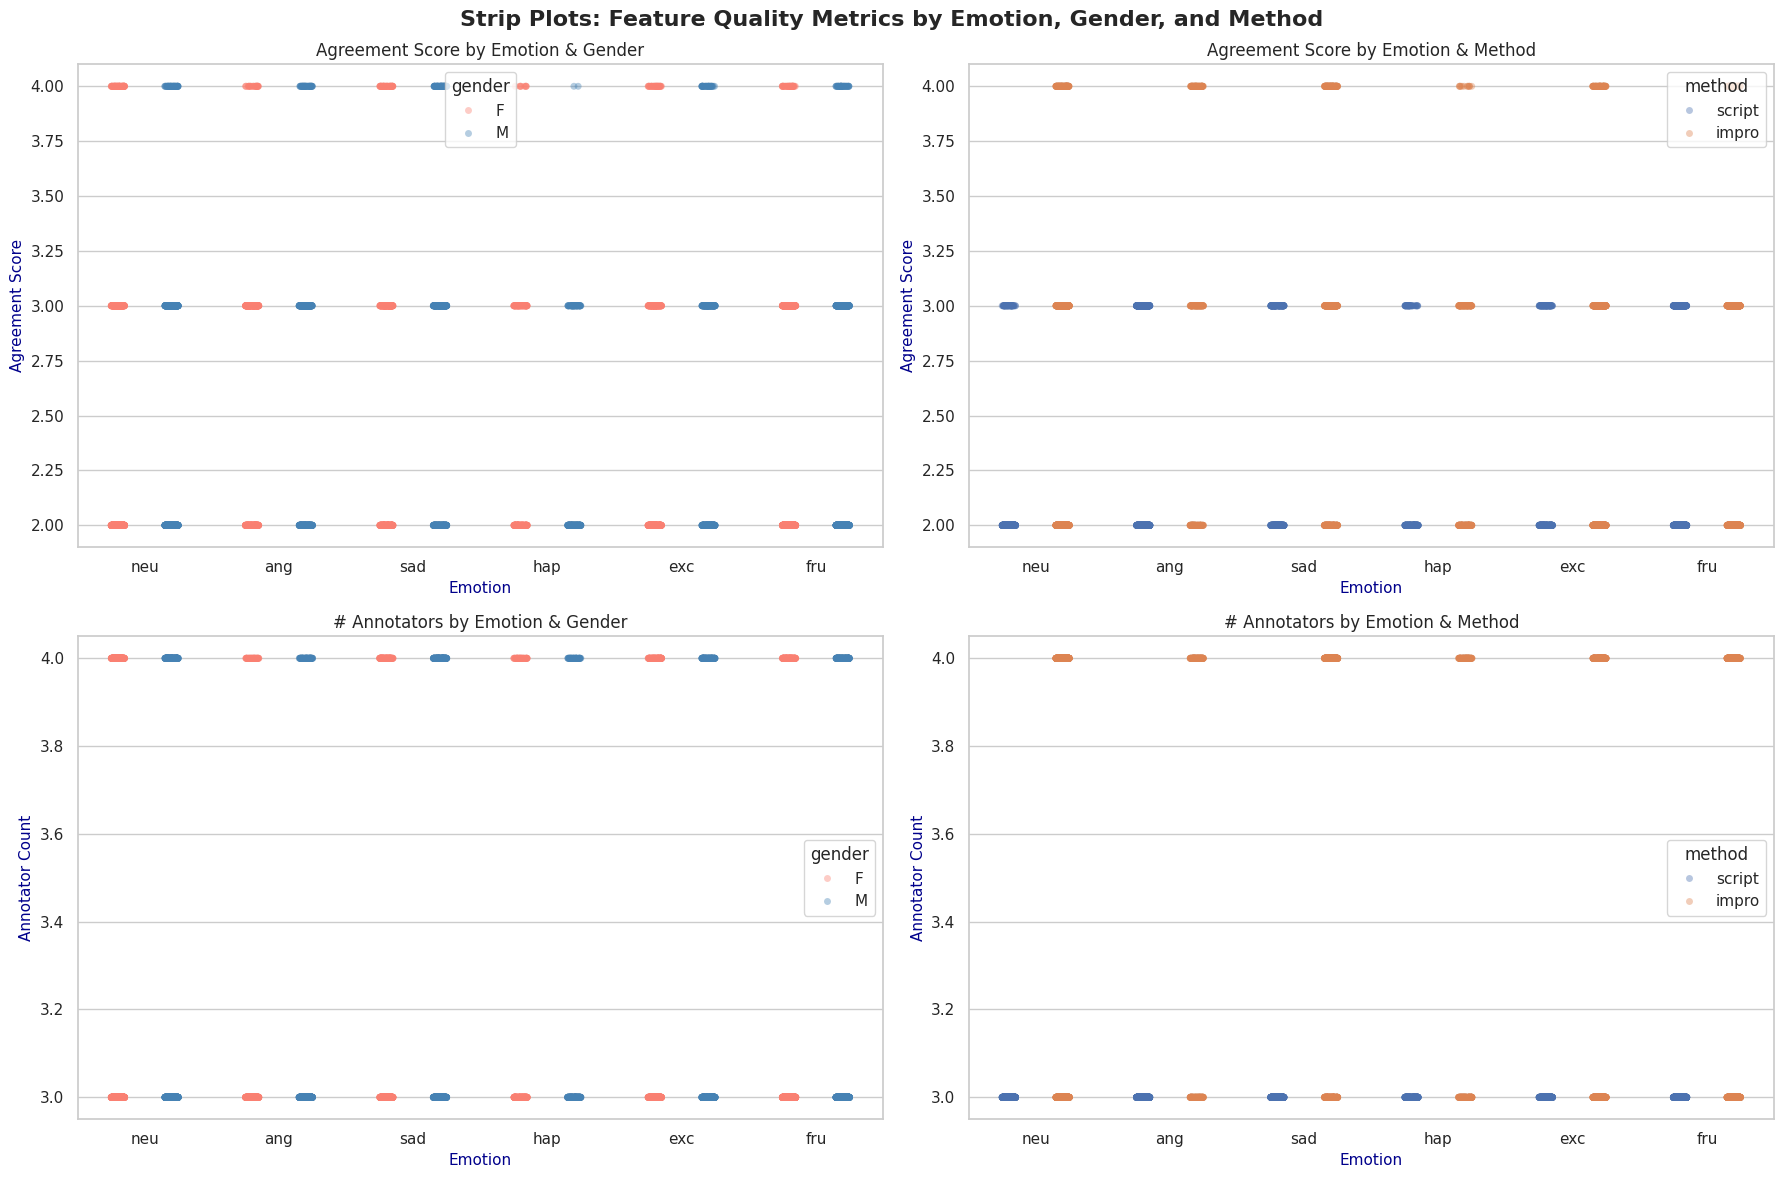

In [35]:
# Strip plot grid  agreement & n_annotators by emotion, split by gender
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

CORE_ORDER = ['neu', 'ang', 'sad', 'hap', 'exc', 'fru']

sns.stripplot(data=cData_core, x='emotion', y='agreement',
              hue='gender', order=CORE_ORDER, palette=PALETTE_GENDER,
              dodge=True, alpha=0.4, ax=axes[0][0])
axes[0][0].set_title('Agreement Score by Emotion & Gender')
axes[0][0].set_xlabel('Emotion', fontsize=11, color='darkblue')
axes[0][0].set_ylabel('Agreement Score', fontsize=11, color='darkblue')

sns.stripplot(data=cData_core, x='emotion', y='agreement',
              hue='method', order=CORE_ORDER, palette=PALETTE_METHOD,
              dodge=True, alpha=0.4, ax=axes[0][1])
axes[0][1].set_title('Agreement Score by Emotion & Method')
axes[0][1].set_xlabel('Emotion', fontsize=11, color='darkblue')
axes[0][1].set_ylabel('Agreement Score', fontsize=11, color='darkblue')

sns.stripplot(data=cData_core, x='emotion', y='n_annotators',
              hue='gender', order=CORE_ORDER, palette=PALETTE_GENDER,
              dodge=True, alpha=0.4, ax=axes[1][0])
axes[1][0].set_title('# Annotators by Emotion & Gender')
axes[1][0].set_xlabel('Emotion', fontsize=11, color='darkblue')
axes[1][0].set_ylabel('Annotator Count', fontsize=11, color='darkblue')

sns.stripplot(data=cData_core, x='emotion', y='n_annotators',
              hue='method', order=CORE_ORDER, palette=PALETTE_METHOD,
              dodge=True, alpha=0.4, ax=axes[1][1])
axes[1][1].set_title('# Annotators by Emotion & Method')
axes[1][1].set_xlabel('Emotion', fontsize=11, color='darkblue')
axes[1][1].set_ylabel('Annotator Count', fontsize=11, color='darkblue')

fig.suptitle('Strip Plots: Feature Quality Metrics by Emotion, Gender, and Method',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


<u>*Agreement  general:*</u>
1. `ang` and `hap` have the tightest agreement score clusters, meaning annotators find these emotions easiest to agree on.

<u>*Agreement  by gender:*</u>
1. No meaningful difference between M and F across any emotion class.

<u>*Agreement  by method:*</u>
1. Scripted `fru` achieves lower agreement than scripted `ang`, suggesting frustration is harder to portray convincingly in scripted contexts.

<u>*Annotator count:*</u>
1. Distributed uniformly across emotions and genders  no systematic sampling bias.


---
## 5.8 Visual Feature Relationships


Pairplot of all numeric features to spot distributional patterns and co-variation at a glance.


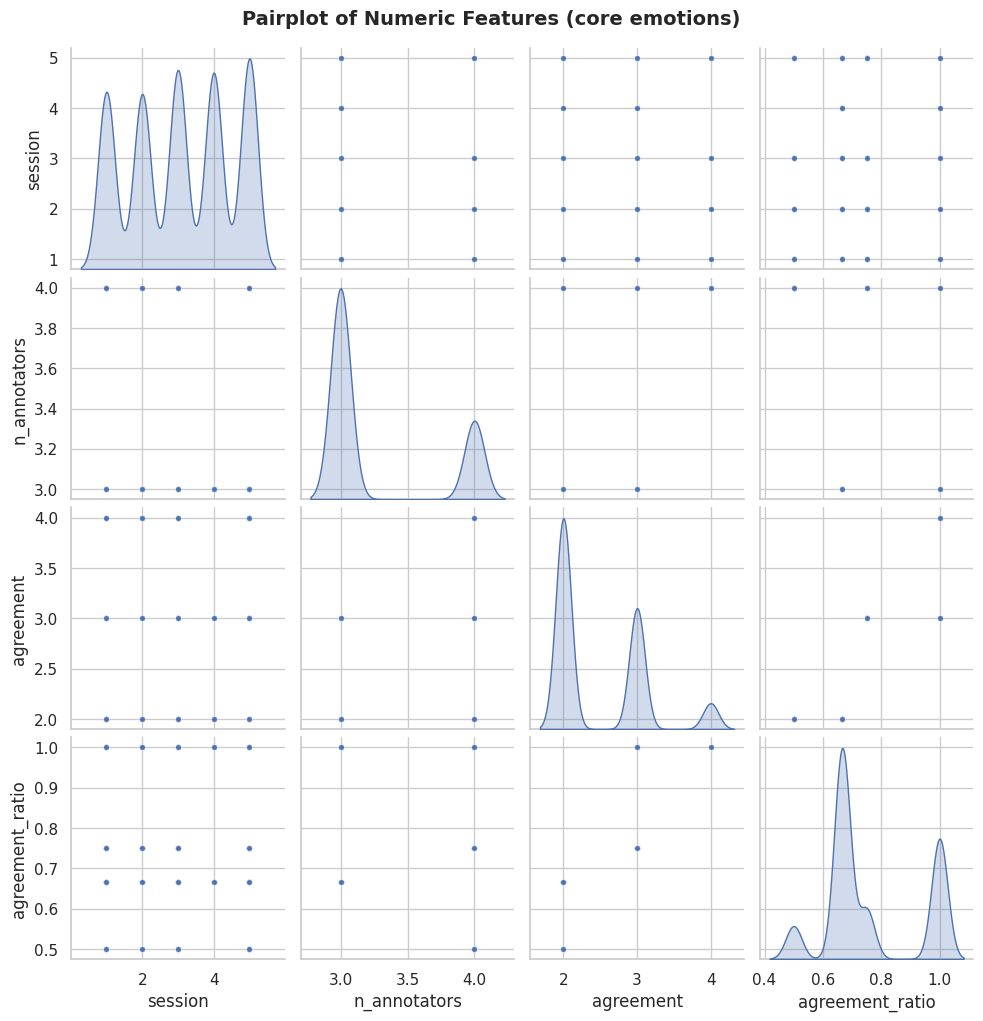

In [36]:
numeric_cols = ['session', 'n_annotators', 'agreement', 'agreement_ratio']
sns.pairplot(cData_core[numeric_cols].dropna(), diag_kind='kde',
             plot_kws={'alpha': 0.3, 's': 15})
plt.suptitle('Pairplot of Numeric Features (core emotions)', y=1.02,
             fontsize=14, fontweight='bold')
plt.show()


The pairplot shows that `agreement` and `agreement_ratio` move together closely, which is expected given how the ratio is constructed. `session` is essentially independent of both agreement metrics, and `n_annotators` clusters tightly  confirming the annotation protocol was consistent across the corpus.


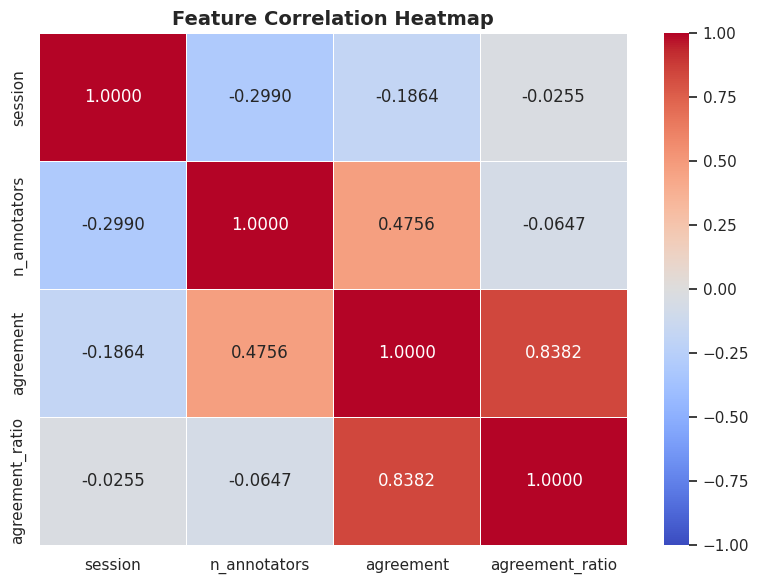

In [37]:
numeric_cols = ['session', 'n_annotators', 'agreement', 'agreement_ratio']
plot_correlation_heatmap(cData_core.dropna(), numeric_cols)


<u>**Correlation heatmap observations:**</u>

1. `agreement` and `agreement_ratio` are strongly correlated  they measure the same phenomenon at different scales, so using either one in analysis is sufficient.
2. `n_annotators` shows a moderate positive association with `agreement`: utterances reviewed by more annotators naturally accumulate higher raw agreement counts.
3. `session` is uncorrelated with both agreement metrics, confirming that label quality is uniform across all recording sessions.


# <h1 style='color:purple;'>**EDA Conclusions**</h1>

## Key Findings

1. **Severe class imbalance in emotion labels.**  
   `xxx` accounts for ~25 % of all utterances. Among the six core emotions, `fru` (N ≈ 1 849) is roughly 3× more frequent than `hap` (N ≈ 595). Any analysis on emotion content should account for this skew.

2. **Elicitation method strongly shapes emotion distribution.**  
   `fru` (frustration) appears almost exclusively in improvised sessions, while scripted sessions concentrate more `neu` and `sad`. The method variable is a major structural dimension of this dataset.

3. **Gender is balanced and does not influence annotation quality.**  
   Male and female speakers contribute near-equal utterance counts across all sessions, and their agreement ratios are indistinguishable  no gender-driven annotation bias is present.

4. **Anger and happiness are the most consistently labelled emotions.**  
   Both show the tightest agreement score distributions, indicating these categories are most unambiguously expressed in the corpus.

5. **Agreement ratio is a more interpretable quality metric than raw agreement.**  
   It normalises for the variable number of annotators per utterance, enabling fair utterance-level comparisons across the full dataset.

6. **Session is a meaningful structural variable.**  
   Sessions 3–5 are slightly larger, and session-specific emotion proportions vary (e.g., `exc` is more prominent in sessions 4–5). Session-level patterns are worth examining when analysing subsets of the data.
